In [1]:
import sys
from pathlib import Path
import os
from mmengine import Config
import time
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import torch
import numpy as np


parent_folder = Path(os.getcwd()).parent  # parent of current folder
sys.path.insert(0, str(parent_folder))


from PhaseDataset import PhaseDataset

In [2]:
device = 'cuda' # set to "cpu" if Cuda is not available
    
paramfile = 'dataset_params.py'  # file of experimental parameters


# Config extraction
AtmosParams = Config.fromfile(paramfile)['AtmosParams']
WFSParams = Config.fromfile(paramfile)['WFSParams']
LoopParams = Config.fromfile(paramfile)['LoopParams']

# Dataset creation
dataset = PhaseDataset(WFSParams, AtmosParams, LoopParams, device)

c:\Users\foyarzun\AppData\Local\anaconda3\envs\AO\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4319.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


## Generate open loop phases

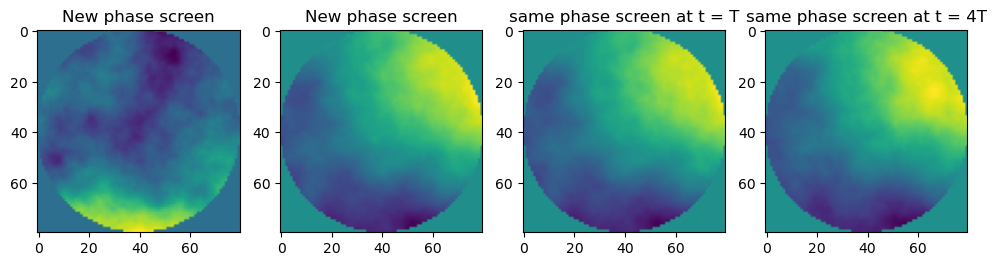

In [ ]:
plt.figure(figsize=(12,3))
## You can get the phase, decomposition and many other parameters by getting a dataset item
phaseGT,pupilGT,zernike,photons,RON,r0,wind_speed,fractional_r0 = dataset[0]
plt.subplot(141)
plt.title('New phase screen')
plt.imshow(phaseGT[0].cpu())

## Each subsequent item 0 call generate a new wavefront
phaseGT,pupilGT,zernike,photons,RON,r0,wind_speed,fractional_r0 = dataset[0]
plt.subplot(142)
plt.title('New phase screen')
plt.imshow(phaseGT[0].cpu())

## Calling the next items will advance the phase screen to the i-th time
phaseGT,pupilGT,zernike,photons,RON,r0,wind_speed,fractional_r0 = dataset[1]
plt.subplot(143)
plt.title('same phase screen at t = T')
plt.imshow(phaseGT[0].cpu())

phaseGT,pupilGT,zernike,photons,RON,r0,wind_speed,fractional_r0 = dataset[4]
plt.subplot(144)
plt.title('same phase screen at t = 4T')
plt.imshow(phaseGT[0].cpu())

KeyboardInterrupt: 

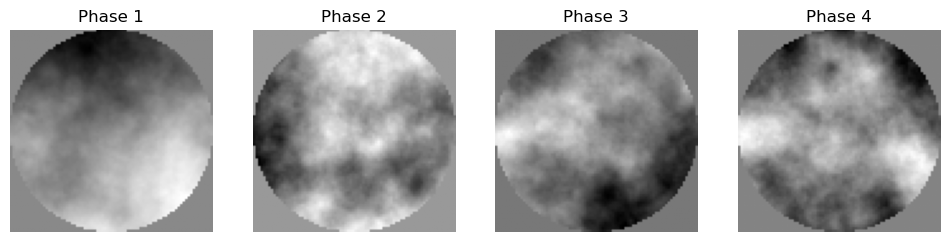

In [16]:
## You can see how the wavefronts move given the wind
n_iter = 100

for i in range(n_iter):
    phaseGT,pupilGT,zernike,_,_,_,wind,_ = dataset[i]
    
    clear_output(wait=True)

    frames = phaseGT[:4]

    num_frames = frames.shape[0]

    # Create subplots: 1 row, num_frames columns
    fig, axes = plt.subplots(1, num_frames, figsize=(3*num_frames, 3))
    
    # Ensure axes is iterable if num_frames = 1
    if num_frames == 1:
        axes = [axes]

    for j, frame in enumerate(frames.cpu()):
        axes[j].imshow(frame, cmap='gray')
        axes[j].set_title(f"Phase {j+1}")
        axes[j].axis('off')


    # Display the frame
    display(plt.gcf())
    
    # Pause so you can see the frame (adjust as needed)
    time.sleep(0.01)

    # Close the figure to prevent memory buildup
    plt.close()

## Generate closed loop phases

In [17]:
dataset.generateClosedLoop = True

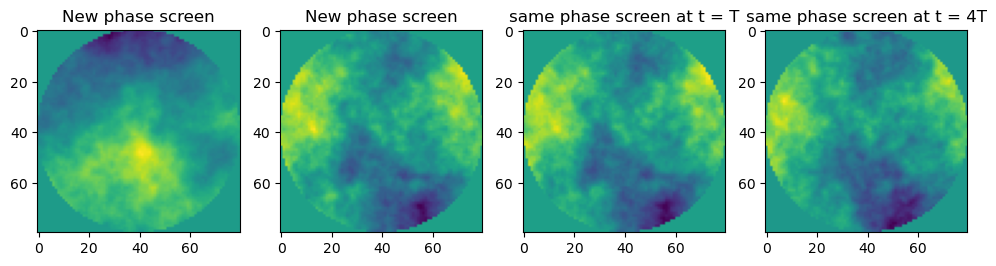

In [ ]:
plt.figure(figsize=(12,3))
## You can get the phase, decomposition and many other parameters by getting a dataset item
phaseGT,pupilGT,zernike,photons,RON,r0,wind_speed,fractional_r0 = dataset[0]
plt.subplot(141)
plt.title('New phase screen')
plt.imshow(phaseGT[0].cpu())

## Each subsequent item 0 call generate a new wavefront
phaseGT,pupilGT,zernike,photons,RON,r0,wind_speed,fractional_r0 = dataset[0]
plt.subplot(142)
plt.title('New phase screen')
plt.imshow(phaseGT[0].cpu())

## Calling the next items will advance the phase screen to the i-th time
phaseGT,pupilGT,zernike,photons,RON,r0,wind_speed,fractional_r0 = dataset[1]
plt.subplot(143)
plt.title('same phase screen at t = T')
plt.imshow(phaseGT[0].cpu())

phaseGT,pupilGT,zernike,photons,RON,r0,wind_speed,fractional_r0 = dataset[4]
plt.subplot(144)
plt.title('same phase screen at t = 4T')
plt.imshow(phaseGT[0].cpu())

KeyboardInterrupt: 

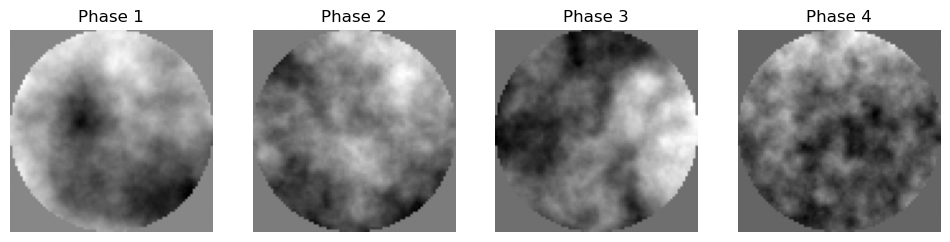

In [19]:
## You can see how the wavefronts move given the wind
n_iter = 100

for i in range(n_iter):
    phaseGT,pupilGT,zernike,_,_,_,wind,_ = dataset[i]
    
    clear_output(wait=True)

    frames = phaseGT[:4]

    num_frames = frames.shape[0]

    # Create subplots: 1 row, num_frames columns
    fig, axes = plt.subplots(1, num_frames, figsize=(3*num_frames, 3))
    
    # Ensure axes is iterable if num_frames = 1
    if num_frames == 1:
        axes = [axes]

    for j, frame in enumerate(frames.cpu()):
        axes[j].imshow(frame, cmap='gray')
        axes[j].set_title(f"Phase {j+1}")
        axes[j].axis('off')


    # Display the frame
    display(plt.gcf())
    
    # Pause so you can see the frame (adjust as needed)
    time.sleep(0.01)

    # Close the figure to prevent memory buildup
    plt.close()

## Add scintillation!

In [20]:
AtmosParams['Scintillation'] = True

# Dataset creation
dataset = PhaseDataset(WFSParams, AtmosParams, LoopParams, device)

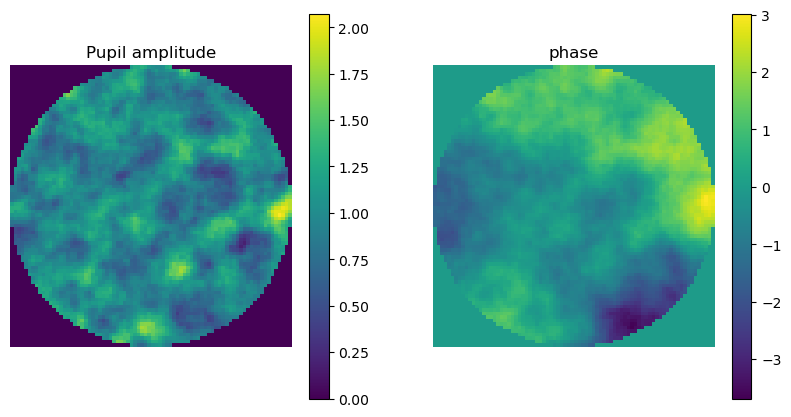

In [33]:
phaseGT,pupilGT,zernike,photons,RON,r0,wind_speed,fractional_r0 = dataset[0]
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.imshow(pupilGT[0].cpu() * dataset.pupil.cpu())
plt.title('Pupil amplitude')
plt.axis('off')
plt.colorbar()
plt.subplot(122)
plt.imshow(phaseGT[0].cpu())
plt.title('phase')
plt.axis('off')
plt.colorbar()

## Check the normalized Cn2 profile

Text(0, 0.5, '$C_n^2$')

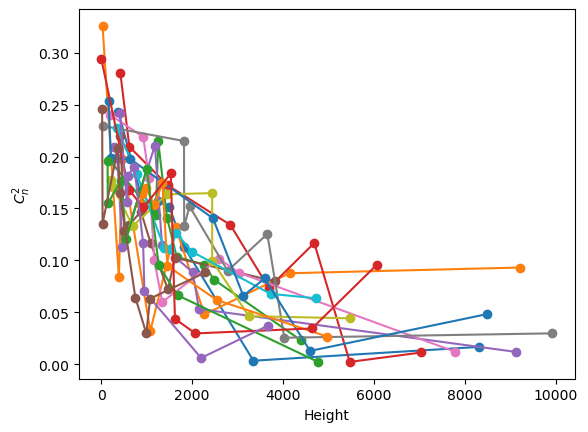

In [ ]:
for index in range(dataset.layerHeights.shape[1]):
    plt.plot(dataset.layerHeights.cpu()[:,index].squeeze(), dataset.fractionalr0.cpu()[:,index].squeeze(), 'o-')

plt.xlabel('Height (m)')
plt.ylabel('Relative $C_n^2$')

KeyboardInterrupt: 

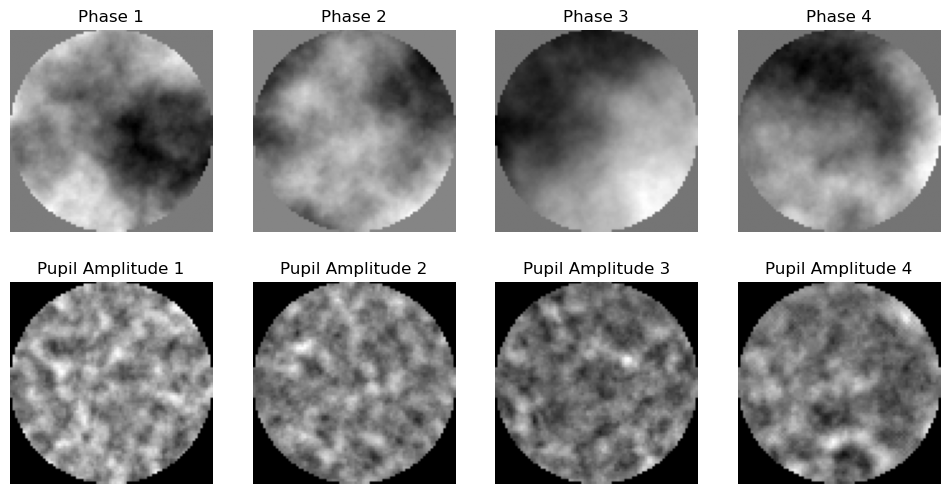

In [35]:
## You can see how the wavefronts move given the wind

n_iter = 100
dataset.ResetMovingWavefront()
for i in range(n_iter):
    phaseGT,pupilGT,zernike,_,_,_,wind,_ = dataset[i]
    # Clear previous output (without flickering)
    clear_output(wait=True)

    frames = phaseGT[:4].cpu()
    pupils = pupilGT[:4].cpu()
    main_pupil = dataset.pupil.cpu()

    num_frames = frames.shape[0]

    # Create subplots: 1 row, num_frames columns
    fig, axes = plt.subplots(2, num_frames, figsize=(3*num_frames, 6))
    
    # Ensure axes is iterable if num_frames = 1
    if num_frames == 1:
        axes = [axes]

    for j, frame in enumerate(frames):
        axes[0,j].imshow(frame, cmap='gray')
        axes[0,j].set_title(f"Phase {j+1}")
        axes[0,j].axis('off')
        axes[1,j].imshow(pupils[j] * main_pupil, cmap='gray')
        axes[1,j].set_title(f"Pupil Amplitude {j+1}")
        axes[1,j].axis('off')

    # Display the frame
    display(plt.gcf())
    
    # Pause so you can see the frame (adjust as needed)
    time.sleep(0.01)

    # Close the figure to prevent memory buildup
    plt.close()

### To see the full support for the scintillation do this...

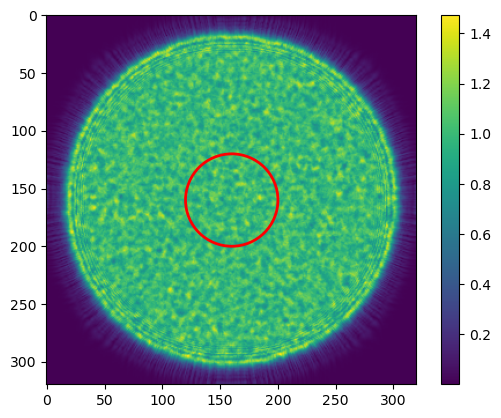

In [17]:
from matplotlib.patches import Circle

phasor = dataset.ComputeScintillation(dataset.scintillationLayeredPhase)
support = phasor.abs()

plt.imshow(support[0].cpu())

## This is the actual telescope pupil
circle = Circle((support.shape[-2]/2, support.shape[-1]/2), dataset.Nres/2,
                fill=False, color='red', linewidth=2)

plt.gca().add_patch(circle)

plt.colorbar()